# VSAT dish 3GPP pattern check

这个 notebook 用 `vsat_dish_3gpp.py` 里的实现，沿主瓣 `+x` 方向做一个 `x-z` 平面切片，画出与 3GPP 图 6.4.1-1 同类型的 `Relative antenna gain (dB)` 曲线。

如果当前环境没有安装 `mitsuba/drjit/sionna`，下面的加载单元会自动注入轻量 stub，这样仍然可以直接复用 `vsat_dish_3gpp.py` 里的函数做验证。


In [1]:
import importlib.util
import sys
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import jv

MODULE_CANDIDATES = [
    Path.cwd() / "vsat_dish_3gpp.py",
    Path.cwd() / "NTN-NULLING-NONCOH" / "vsat_dish_3gpp.py",
]
MODULE_PATH = next((p for p in MODULE_CANDIDATES if p.exists()), None)
assert MODULE_PATH is not None, f"Cannot find vsat_dish_3gpp.py from {Path.cwd()}"

def _install_stub_modules_if_needed():
    try:
        import mitsuba  # noqa: F401
        import drjit  # noqa: F401
        from sionna.rt.antenna_pattern import PolarizedAntennaPattern, register_antenna_pattern  # noqa: F401
        return False
    except ModuleNotFoundError:
        pass

    mi_stub = types.ModuleType("mitsuba")
    mi_stub.Float = lambda x: np.asarray(x, dtype=np.float64)
    mi_stub.Complex2f = lambda re, im: np.asarray(re, dtype=np.complex128) + 1j * np.asarray(im, dtype=np.complex128)

    dr_stub = types.ModuleType("drjit")

    antenna_pattern_stub = types.ModuleType("sionna.rt.antenna_pattern")

    class PolarizedAntennaPattern:
        def __init__(self, v_pattern, polarization, polarization_model="tr38901_2"):
            self.v_pattern = v_pattern
            self.polarization = polarization
            self.polarization_model = polarization_model

    _pattern_registry = {}

    def register_antenna_pattern(name, factory):
        _pattern_registry[name] = factory

    antenna_pattern_stub.PolarizedAntennaPattern = PolarizedAntennaPattern
    antenna_pattern_stub.register_antenna_pattern = register_antenna_pattern
    antenna_pattern_stub._pattern_registry = _pattern_registry

    rt_stub = types.ModuleType("sionna.rt")
    rt_stub.antenna_pattern = antenna_pattern_stub

    sionna_stub = types.ModuleType("sionna")
    sionna_stub.rt = rt_stub

    sys.modules.setdefault("mitsuba", mi_stub)
    sys.modules.setdefault("drjit", dr_stub)
    sys.modules.setdefault("sionna", sionna_stub)
    sys.modules.setdefault("sionna.rt", rt_stub)
    sys.modules.setdefault("sionna.rt.antenna_pattern", antenna_pattern_stub)
    return True

using_stubs = _install_stub_modules_if_needed()

spec = importlib.util.spec_from_file_location("vsat_dish_3gpp", MODULE_PATH)
vsat_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(vsat_module)

print(f"Loaded: {MODULE_PATH.name}")
print(f"Using stub modules: {using_stubs}")
print("Registered pattern name: vsat_dish")


Loaded: vsat_dish_3gpp.py
Using stub modules: False
Registered pattern name: vsat_dish


In [2]:
aperture_radius_lambda = 10.0
frequency_hz = 10e9
theta_deg = np.linspace(-90.0, 90.0, 4001)
theta_offset_rad = np.deg2rad(theta_deg)

# x-z plane cut around the +x boresight used in vsat_dish_3gpp.py
theta_sionna = np.pi / 2 - theta_offset_rad
phi_sionna = np.zeros_like(theta_sionna)

field = vsat_module.v_vsat_dish_pattern(
    theta_sionna,
    phi_sionna,
    frequency_hz=frequency_hz,
    aperture_radius_lambda=aperture_radius_lambda,
)
field = field.numpy() if hasattr(field, "numpy") else np.asarray(field)
gain_linear_from_file = np.abs(field) ** 2
gain_relative_db_from_file = 10 * np.log10(np.maximum(gain_linear_from_file, 1e-12) / np.max(gain_linear_from_file))

u = 2 * np.pi * aperture_radius_lambda * np.sin(np.abs(theta_offset_rad))
u_safe = np.where(np.abs(u) < 1e-12, 1e-12, u)
gain_linear_formula = (2 * jv(1, u_safe) / u_safe) ** 2
gain_linear_formula = np.where(np.abs(u) < 1e-12, 1.0, gain_linear_formula)
gain_relative_db_formula = 10 * np.log10(np.maximum(gain_linear_formula, 1e-12))

max_abs_err_db = np.max(np.abs(gain_relative_db_from_file - gain_relative_db_formula))
print(f"Max |implementation - formula| = {max_abs_err_db:.6e} dB")


Max |implementation - formula| = 1.485126e-05 dB


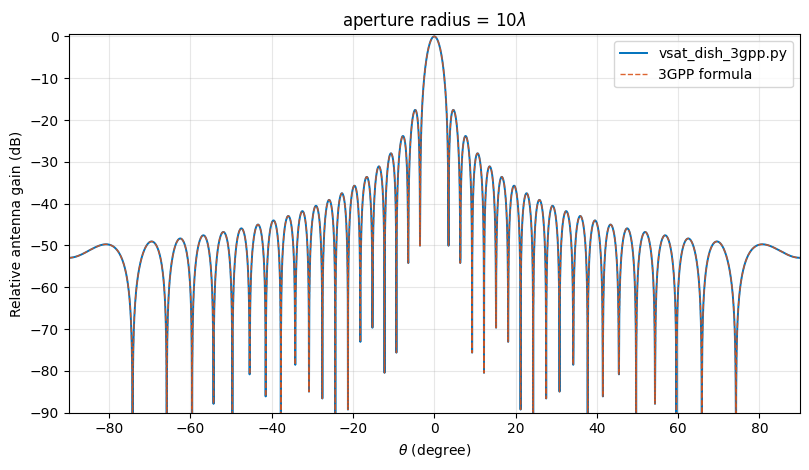

In [3]:
plt.figure(figsize=(8.2, 4.8))
plt.plot(theta_deg, gain_relative_db_from_file, color="#0072BD", linewidth=1.4, label="vsat_dish_3gpp.py")
plt.plot(theta_deg, gain_relative_db_formula, color="#D95319", linewidth=1.0, linestyle="--", alpha=0.9, label="3GPP formula")
plt.xlim(-90, 90)
plt.ylim(-90, 0.5)
plt.xticks(np.arange(-80, 81, 20))
plt.yticks(np.arange(-90, 10, 10))
plt.grid(True, alpha=0.3)
plt.xlabel(r"$\theta$ (degree)")
plt.ylabel("Relative antenna gain (dB)")
plt.title(r"aperture radius = 10$\lambda$")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
sample_angles_deg = np.array([0, 1, 2, 5, 10, 20, 40, 80])
sample_idx = [np.argmin(np.abs(theta_deg - ang)) for ang in sample_angles_deg]
for ang, idx in zip(sample_angles_deg, sample_idx):
    print(f"theta = {ang:>5.1f} deg : {gain_relative_db_from_file[idx]:>8.3f} dB")
